Hybrid - 3 Day LSTM

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from lightgbm import LGBMRegressor

In [2]:
# Load dataset
df = pd.read_csv("boralesgamuwa_weather_2025_01_01_to_2025_12_31_15min_interpolated_power_added_final_set.csv")

# Convert timestamp
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Sort by time (VERY IMPORTANT)
df = df.sort_values("timestamp").reset_index(drop=True)

df.head()

,timestamp,temperature_C,humidity_percent,cloud_cover_percent,solar_irradiance_Wm2,wind_speed_ms,solar_normalize
0,2025-01-01 00:00:00,24.2,92.0,100.0,0.0,8.100,0.0
1,2025-01-01 00:15:00,24.1,92.5,100.0,0.0,8.275,0.0
2,2025-01-01 00:30:00,24.0,93.0,100.0,0.0,8.450,0.0
3,2025-01-01 00:45:00,23.9,93.5,100.0,0.0,8.625,0.0
4,2025-01-01 01:00:00,23.8,94.0,100.0,0.0,8.800,0.0


In [3]:
df.tail()

,timestamp,temperature_C,humidity_percent,cloud_cover_percent,solar_irradiance_Wm2,wind_speed_ms,solar_normalize
35035,2025-12-31 22:45:00,24.15,94.0,100.0,0.0,6.2,0.0
35036,2025-12-31 23:00:00,24.30,94.0,100.0,0.0,6.0,0.0
35037,2025-12-31 23:15:00,24.45,94.0,100.0,0.0,5.8,0.0
35038,2025-12-31 23:30:00,24.60,94.0,100.0,0.0,5.6,0.0
35039,2025-12-31 23:45:00,24.75,94.0,100.0,0.0,5.4,0.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   timestamp             35040 non-null  datetime64[ns]
 1   temperature_C         35040 non-null  float64       
 2   humidity_percent      35040 non-null  float64       
 3   cloud_cover_percent   35040 non-null  float64       
 4   solar_irradiance_Wm2  35040 non-null  float64       
 5   wind_speed_ms         35040 non-null  float64       
 6   solar_normalize       34956 non-null  float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 1.9 MB


In [5]:
#  Interpolate missing values (linear for time series)
df = df.interpolate(method="linear")
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   timestamp             35040 non-null  datetime64[ns]
 1   temperature_C         35040 non-null  float64       
 2   humidity_percent      35040 non-null  float64       
 3   cloud_cover_percent   35040 non-null  float64       
 4   solar_irradiance_Wm2  35040 non-null  float64       
 5   wind_speed_ms         35040 non-null  float64       
 6   solar_normalize       35040 non-null  float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 1.9 MB
None


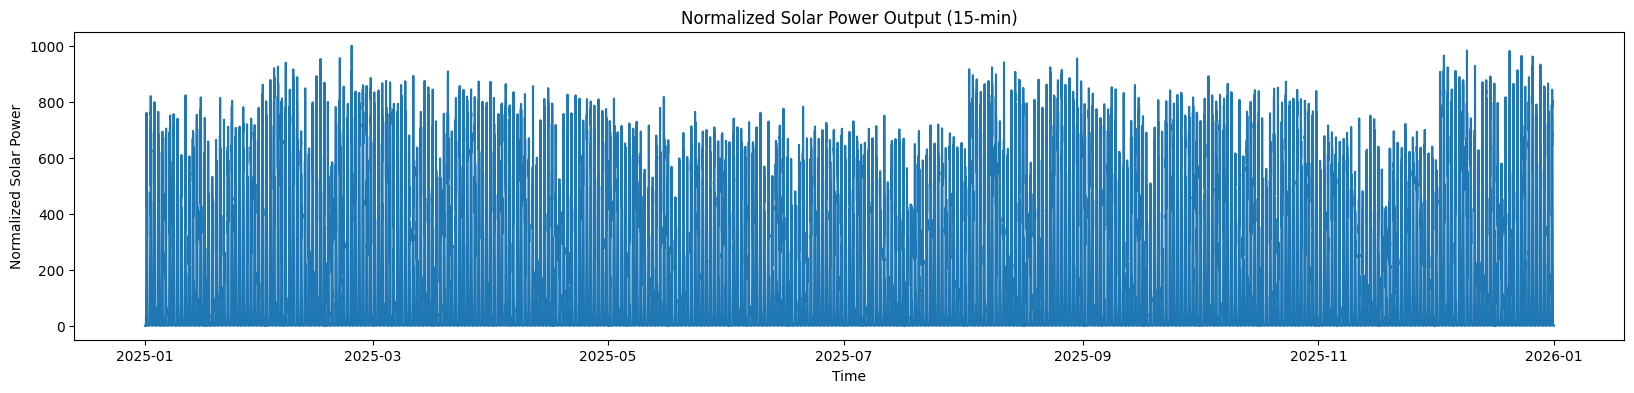

In [6]:
plt.figure(figsize=(20,4))
plt.plot(df["timestamp"], df["solar_normalize"])
plt.title("Normalized Solar Power Output (15-min)")
plt.xlabel("Time")
plt.ylabel("Normalized Solar Power")
plt.show()

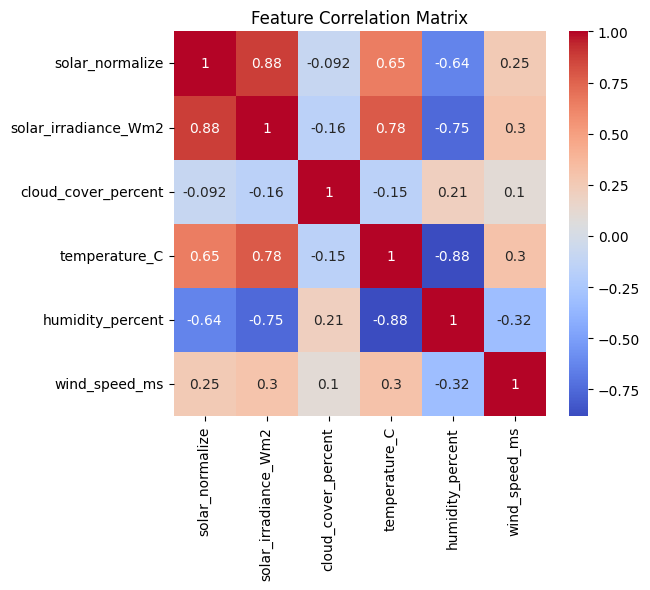

In [7]:
plt.figure(figsize=(6,5))
sns.heatmap(
    df[[
        "solar_normalize",
        "solar_irradiance_Wm2",
        "cloud_cover_percent",
        "temperature_C",
        "humidity_percent",
        "wind_speed_ms"
    ]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Feature Correlation Matrix")
plt.show()

In [8]:
# Time-based features
df["hour"] = df["timestamp"].dt.hour
df["minute"] = df["timestamp"].dt.minute
df["dayofyear"] = df["timestamp"].dt.dayofyear

# Solar power lags
# df["solar_lag_1"] = df["solar_normalize"].shift(1)
# df["solar_lag_2"] = df["solar_normalize"].shift(2)
# df["solar_lag_4"] = df["solar_normalize"].shift(4)

# Ramp rate (intra-hour variability)
#df["solar_ramp"] = df["solar_normalize"] - df["solar_lag_1"]

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   timestamp             35040 non-null  datetime64[ns]
 1   temperature_C         35040 non-null  float64       
 2   humidity_percent      35040 non-null  float64       
 3   cloud_cover_percent   35040 non-null  float64       
 4   solar_irradiance_Wm2  35040 non-null  float64       
 5   wind_speed_ms         35040 non-null  float64       
 6   solar_normalize       35040 non-null  float64       
 7   hour                  35040 non-null  int32         
 8   minute                35040 non-null  int32         
 9   dayofyear             35040 non-null  int32         
dtypes: datetime64[ns](1), float64(6), int32(3)
memory usage: 2.3 MB


In [10]:
y = df[["solar_normalize"]]
X = df[
    [
        "solar_irradiance_Wm2",
        "temperature_C",
        "wind_speed_ms",
        "hour",
        "minute",
        "dayofyear"
        # "solar_lag_1",
        # "solar_lag_2",
        # "solar_lag_4"
        # "solar_ramp"
    ]
]

In [11]:
len(X), len(y)

(35040, 35040)

In [12]:
X.head()

,solar_irradiance_Wm2,temperature_C,wind_speed_ms,hour,minute,dayofyear
0,0.0,24.2,8.100,0,0,1
1,0.0,24.1,8.275,0,15,1
2,0.0,24.0,8.450,0,30,1
3,0.0,23.9,8.625,0,45,1
4,0.0,23.8,8.800,1,0,1


In [13]:
y.head()

,solar_normalize
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


In [14]:
# Total samples
total_samples = len(df)

# Samples per day (15-min data)
samples_per_day = 96

# Total number of days
total_days = total_samples // samples_per_day

print("Total days:", total_days)

# Split ratios
train_days = int(0.7 * total_days)
val_days   = int(0.15 * total_days)
test_days  = total_days - train_days - val_days

print(train_days, val_days, test_days)

# Convert days → indices
train_end = train_days * samples_per_day
val_end   = train_end + (val_days * samples_per_day)

# Split data (IMPORTANT: no shuffling)
X_train = X.iloc[:train_end]
X_val   = X.iloc[train_end:val_end]
X_test  = X.iloc[val_end:]

y_train = y.iloc[:train_end]
y_val   = y.iloc[train_end:val_end]
y_test  = y.iloc[val_end:]

Total days: 365
255 54 56


In [ ]:
from sklearn.model_selection import ParameterSampler
from lightgbm import early_stopping, log_evaluation

param_dist = {
    "n_estimators": [200, 300, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [4, 6, 8],
    "num_leaves": [20, 31, 50],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

# Randomly sample combinations
param_list = list(ParameterSampler(param_dist, n_iter=15, random_state=42))

best_rmse = float("inf")
best_model = None
best_params = None

for i, params in enumerate(param_list):
    print(f"Trial {i+1}/{len(param_list)}")

    model = LGBMRegressor(random_state=42, **params)

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="rmse",
        callbacks=[
        early_stopping(stopping_rounds=20),log_evaluation(0)
        ],
    )

    y_val_pred = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

    print("RMSE:", rmse)

    if rmse < best_rmse:
        best_rmse = rmse
        best_model = model
        best_params = params


print("\nBest Parameters:", best_params)
print("Best Validation RMSE:", best_rmse)

y_test_pred = best_model.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("Test RMSE:", test_rmse)
print("Best Iteration:", best_model.best_iteration_)

Trial 1/15
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000504 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1048
[LightGBM] [Info] Number of data points in the train set: 24480, number of used features: 6
[LightGBM] [Info] Start training from score 170.312673
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[97]	valid_0's rmse: 110.231	valid_0's l2: 12150.8
RMSE: 110.23079816155247
Trial 2/15
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001472 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1048
[LightGBM] [Info] Number of data points in the train set: 24480, number of used features: 6
[LightGBM] [Info] Start training from score 170.312673
Training until validation scores don't improve for 20 ro

In [75]:
y_pred_fixed = y_test_pred.copy()

# Assuming irradiance is a column in X (e.g., column name)
irradiance_test = X_test["solar_irradiance_Wm2"].values

y_pred_fixed[irradiance_test == 0] = 0

In [230]:
y_test_np = np.array(y_test)
y_pred_np = np.array(y_pred_fixed)

# MAE
test_mae = mean_absolute_error(y_test_np, y_pred_np)

# R2 Score
test_r2 = r2_score(y_test_np, y_pred_np)

# RMSE
test_rmse = np.sqrt(mean_squared_error(y_test_np, y_pred_np))

print("\nTest MAE:", test_mae)
print("Test R2:", test_r2)
print("Test RMSE:", test_rmse)



Test MAE: 61.27918245671373
Test R2: 0.7868968267615817
Test RMSE: 113.48246483505307


In [235]:
y_test_np.shape

(5376, 1)

In [112]:
# y_test_np = np.array(y_test)
# y_pred_np = np.array(y_test_pred)

# # MAE
# test_mae = mean_absolute_error(y_test_np, y_pred_np)

# # R2 Score
# test_r2 = r2_score(y_test_np, y_pred_np)

# # RMSE
# test_rmse = np.sqrt(mean_squared_error(y_test_np, y_pred_np))

# print("\nTest MAE:", test_mae)
# print("Test R2:", test_r2)
# print("Test RMSE:", test_rmse)


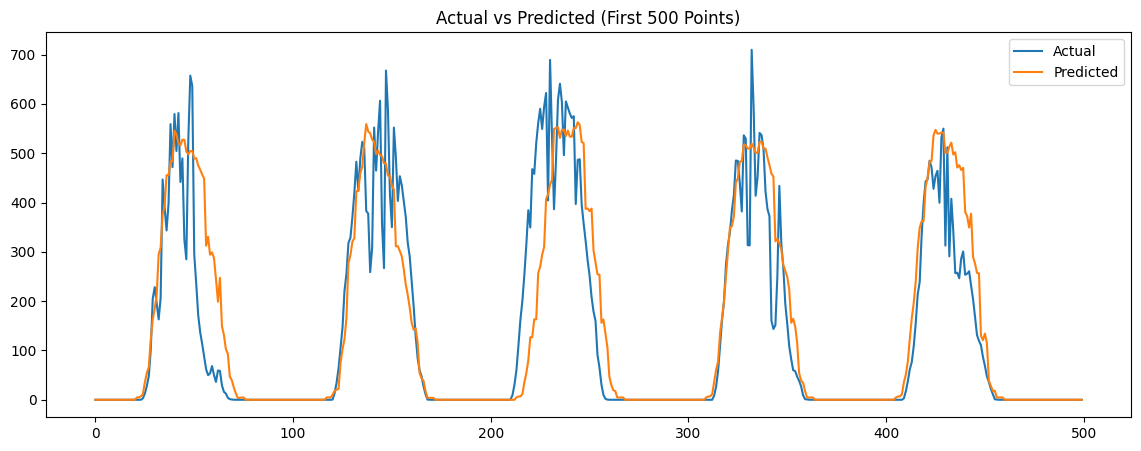

In [77]:
n = 500  # change as needed

plt.figure(figsize=(14,5))

plt.plot(y_test_np[0:500], label="Actual")
plt.plot(y_pred_np[0:500], label="Predicted")

plt.title(f"Actual vs Predicted (First {n} Points)")
plt.legend()

plt.show()

In [117]:
y_pred = best_model.predict(X)
y_pred_fixed_ = y_pred.copy()

# Assuming irradiance is a column in X (e.g., column name)
irradiance = X["solar_irradiance_Wm2"].values

y_pred_fixed_[irradiance == 0] = 0

In [118]:
# Add predictions to dataframe
df["lgb_predicted"] = y_pred_fixed_

# Save to CSV
df.to_csv("output_with_lgb_predictions.csv", index=False)

print("Saved successfully!")

Saved successfully!


In [144]:
residual = df["solar_normalize"] - df["lgb_predicted"]

In [145]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

res_scaler = MinMaxScaler()

res_scaled = res_scaler.fit_transform(residual.values.reshape(-1,1))

In [148]:
n_input = 96 * 3   # 3 days
n_output = 96      # 1 day

X_res = []
y_res = []

for i in range(0, len(res_scaled) - n_input - n_output, 96):
    
    X_res.append(res_scaled[i:i+n_input])
    y_res.append(res_scaled[i+n_input:i+n_input+n_output])

X_res = np.array(X_res)
y_res = np.array(y_res)

print(X_res.shape, y_res.shape)

(361, 288, 1) (361, 96, 1)


In [124]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model_res = Sequential()

model_res.add(LSTM(64, return_sequences=True, input_shape=(n_input,1)))
model_res.add(Dropout(0.2))

model_res.add(LSTM(32))
model_res.add(Dense(n_output))

model_res.compile(optimizer='adam', loss='huber')

model_res.summary()

c:\Users\HP\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 288, 64)        │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 288, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 96)             │         3,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,480 (126.88 KB)

 Trainable params: 32,480 (126.88 KB)

 Non-trainable params: 0 (0.00 B)

In [187]:
train_size = int(0.7 * len(X_res))
val_size   = int(0.15 * len(X_res))

X_train_res = X_res[:train_size]
X_val_res   = X_res[train_size:train_size+val_size]
X_test_res  = X_res[train_size+val_size:]

y_train_res = y_res[:train_size]
y_val_res   = y_res[train_size:train_size+val_size]
y_test_res  = y_res[train_size+val_size:]

In [190]:
train_size+val_size

306

In [127]:
model_res.fit(
    X_train_res, y_train_res,
    epochs=20,
    batch_size=32,
    validation_data=(X_val_res, y_val_res)
)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - loss: 0.0034 - val_loss: 0.0045
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step - loss: 0.0033 - val_loss: 0.0045
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step - loss: 0.0033 - val_loss: 0.0045
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step - loss: 0.0034 - val_loss: 0.0045
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step - loss: 0.0033 - val_loss: 0.0046
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 182ms/step - loss: 0.0034 - val_loss: 0.0046
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 220ms/step - loss: 0.0031 - val_loss: 0.0044
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 240ms/step - loss: 0.0035 - val_loss: 0.0046
Epoch 9/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 196ms/step - loss: 0.0033 - val_loss: 0.0046
Epoch 10/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 207ms/step - loss: 0.0033 - val_loss: 0.0046
Epoch 11/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 186ms/step - loss: 0.0032 - val_loss: 0.0045
Epoch 12/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 187ms/step - loss: 0.0033 - val_lo

In [128]:
res_pred_scaled = model_res.predict(X_test_res)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


In [129]:
res_pred = res_scaler.inverse_transform(
    res_pred_scaled.reshape(-1,1)
).reshape(res_pred_scaled.shape)

In [246]:
y_final = lgb_test_seq + res_pred
# y_final = np.maximum(y_final, 0)

In [247]:
y_final_np = y_final.reshape(-1)
lgb_test_seq_np = lgb_test_seq.reshape(-1)
len(y_final_np), len(y_test_np), len(lgb_test_seq_np)

(5280, 5376, 5280)

In [248]:
len(y_pred_np)
y_test_np = y_test_np.squeeze(-1)

ValueError: cannot select an axis to squeeze out which has size not equal to one

In [250]:

df_results = pd.DataFrame({
    "Actual": y_test_np[0:5280],
    "LightGBM_Pred": y_pred_np[0:5280],
    "Hybrid_Pred": y_final_np
})

df_results.to_excel("hybrid_results.xlsx", index=False)


In [251]:
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score

# Extract columns
y_true = df_results["Actual"].values
y_lgb  = df_results["LightGBM_Pred"].values
y_hyb  = df_results["Hybrid_Pred"].values

# --- LightGBM ---
mae_lgb = mean_absolute_error(y_true, y_lgb)
rmse_lgb = np.sqrt(np.mean((y_true - y_lgb)**2))
r2_lgb = r2_score(y_true, y_lgb)

# --- Hybrid ---
mae_hyb = mean_absolute_error(y_true, y_hyb)
rmse_hyb = np.sqrt(np.mean((y_true - y_hyb)**2))
r2_hyb = r2_score(y_true, y_hyb)

print("LIGHTGBM")
print("MAE:", mae_lgb)
print("RMSE:", rmse_lgb)
print("R2:", r2_lgb)

print("\nHYBRID")
print("MAE:", mae_hyb)
print("RMSE:", rmse_hyb)
print("R2:", r2_hyb)

LIGHTGBM
MAE: 60.94112927542367
RMSE: 112.85531178624366
R2: 0.7879343704368199

HYBRID
MAE: 61.73145132013437
RMSE: 111.37712947796044
R2: 0.7934532729360119
